In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Practice2.csv")

In [ ]:
df.head()

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,discount,payment_method,delivery_days,rating
0,1001,2025-01-03,C101,Pune,Electronics,Wireless Mouse,2,599,0.10,UPI,3,5
1,1002,2025-01-05,C102,Mumbai,Electronics,Keyboard,1,1299,0.05,Credit Card,5,4
2,1003,2025-01-06,C103,Pune,Furniture,Office Chair,1,7499,0.15,UPI,7,3
3,1004,2025-01-08,C104,Delhi,Clothing,T-Shirt,3,799,0.00,Cash,4,5
4,1005,2025-01-10,C105,Mumbai,Electronics,Headphones,2,1999,0.10,Credit Card,6,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        40 non-null     int64  
 1   order_date      40 non-null     object 
 2   customer_id     40 non-null     object 
 3   city            40 non-null     object 
 4   category        40 non-null     object 
 5   product         40 non-null     object 
 6   quantity        40 non-null     int64  
 7   unit_price      40 non-null     int64  
 8   discount        40 non-null     float64
 9   payment_method  40 non-null     object 
 10  delivery_days   40 non-null     int64  
 11  rating          40 non-null     int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 3.9+ KB


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
city,0
category,0
product,0
quantity,0
unit_price,0
discount,0
payment_method,0


In [ ]:
df.drop_duplicates().head()

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,discount,payment_method,delivery_days,rating
0,1001,2025-01-03,C101,Pune,Electronics,Wireless Mouse,2,599,0.10,UPI,3,5
1,1002,2025-01-05,C102,Mumbai,Electronics,Keyboard,1,1299,0.05,Credit Card,5,4
2,1003,2025-01-06,C103,Pune,Furniture,Office Chair,1,7499,0.15,UPI,7,3
3,1004,2025-01-08,C104,Delhi,Clothing,T-Shirt,3,799,0.00,Cash,4,5
4,1005,2025-01-10,C105,Mumbai,Electronics,Headphones,2,1999,0.10,Credit Card,6,4


In [ ]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [ ]:
df["month"]=df["order_date"].dt.month
df["order_day"]=df["order_date"].dt.day
df.head()

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,discount,payment_method,delivery_days,rating,month,order_day
0,1001,2025-01-03,C101,Pune,Electronics,Wireless Mouse,2,599,0.10,UPI,3,5,1,3
1,1002,2025-01-05,C102,Mumbai,Electronics,Keyboard,1,1299,0.05,Credit Card,5,4,1,5
2,1003,2025-01-06,C103,Pune,Furniture,Office Chair,1,7499,0.15,UPI,7,3,1,6
3,1004,2025-01-08,C104,Delhi,Clothing,T-Shirt,3,799,0.00,Cash,4,5,1,8
4,1005,2025-01-10,C105,Mumbai,Electronics,Headphones,2,1999,0.10,Credit Card,6,4,1,10


In [ ]:
df["revenue"]=df["quantity"]*df["unit_price"]*(1-df["discount"])
df.head()

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,discount,payment_method,delivery_days,rating,month,order_day,revenue
0,1001,2025-01-03,C101,Pune,Electronics,Wireless Mouse,2,599,0.10,UPI,3,5,1,3,1078.20
1,1002,2025-01-05,C102,Mumbai,Electronics,Keyboard,1,1299,0.05,Credit Card,5,4,1,5,1234.05
2,1003,2025-01-06,C103,Pune,Furniture,Office Chair,1,7499,0.15,UPI,7,3,1,6,6374.15
3,1004,2025-01-08,C104,Delhi,Clothing,T-Shirt,3,799,0.00,Cash,4,5,1,8,2397.00
4,1005,2025-01-10,C105,Mumbai,Electronics,Headphones,2,1999,0.10,Credit Card,6,4,1,10,3598.20


In [ ]:
total_revenue=df["revenue"].sum()
total_orders=df["order_id"].count()
total_quantity_sold=df["quantity"].sum()
average_order_value=df["revenue"].mean()

In [ ]:
quantity_sold=df.groupby("product")["quantity"].sum().sort_values()
average_selling_price=df.groupby("product")["revenue"].mean().sort_values().round(1)
number_of_orders=df.groupby("product")["quantity"].count().sort_values()

<Axes: ylabel='product'>

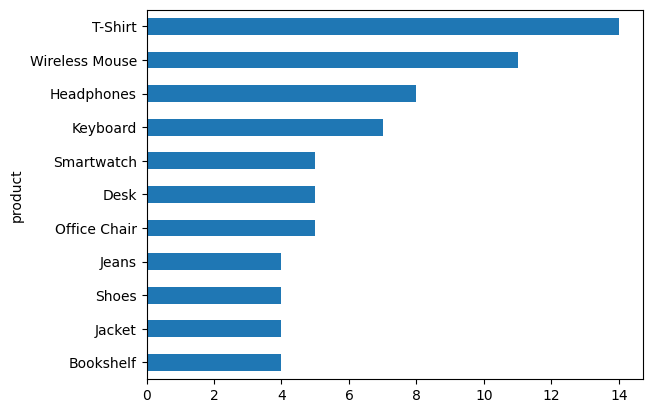

In [ ]:
quantity_sold.plot(kind="barh")

<Axes: ylabel='product'>

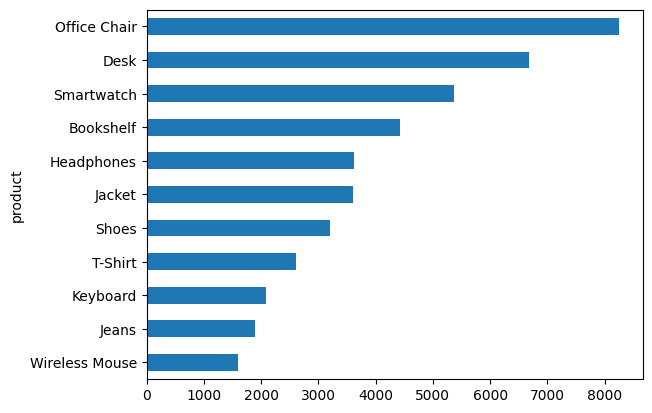

In [ ]:
average_selling_price.plot(kind="barh")

<Axes: ylabel='product'>

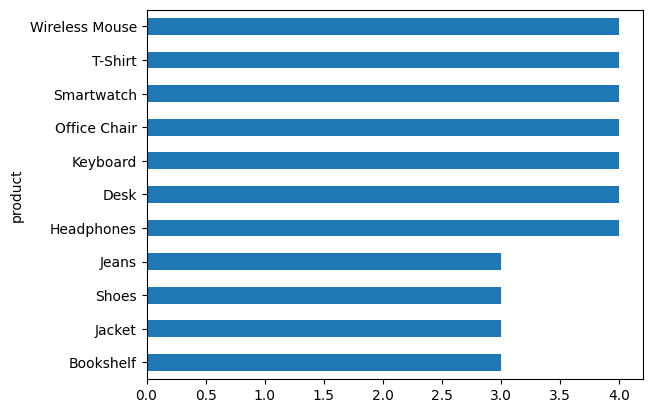

In [ ]:
number_of_orders.plot(kind="barh")

In [ ]:
category_revenue=df.groupby("category")["revenue"].sum().sort_values()

<Axes: ylabel='category'>

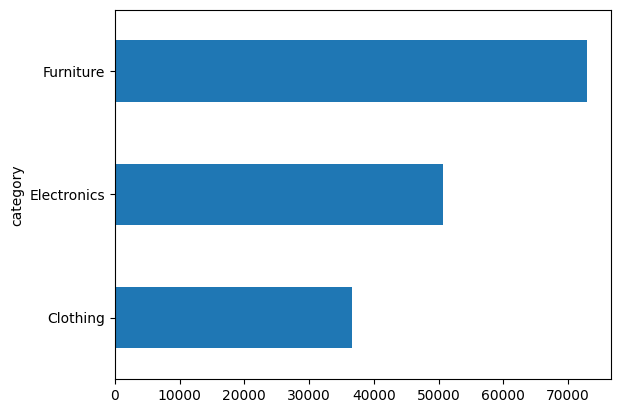

In [ ]:
category_revenue.plot(kind="barh")

In [ ]:
city_revenue=df.groupby("city")["revenue"].sum().sort_values()
city_orders=df.groupby("city")["order_id"].count().sort_values()
city_order_average=df.groupby("city")["revenue"].mean().sort_values()

<Axes: ylabel='city'>

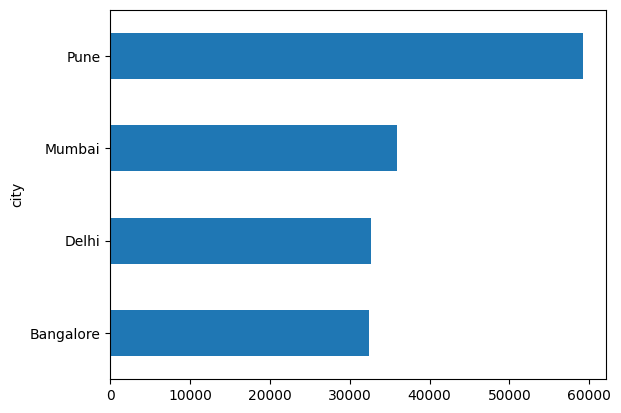

In [ ]:
city_revenue.plot(kind="barh")

<Axes: ylabel='city'>

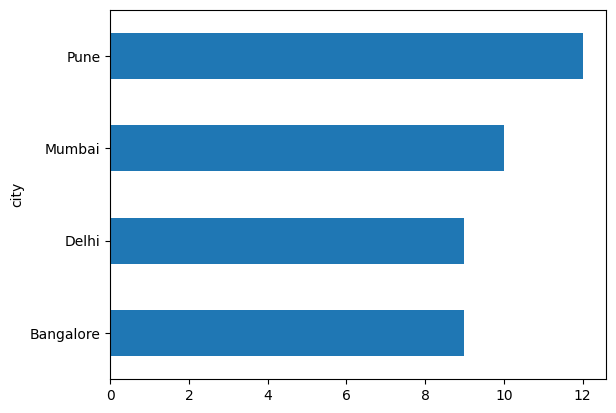

In [ ]:
city_orders.plot(kind="barh")

<Axes: ylabel='city'>

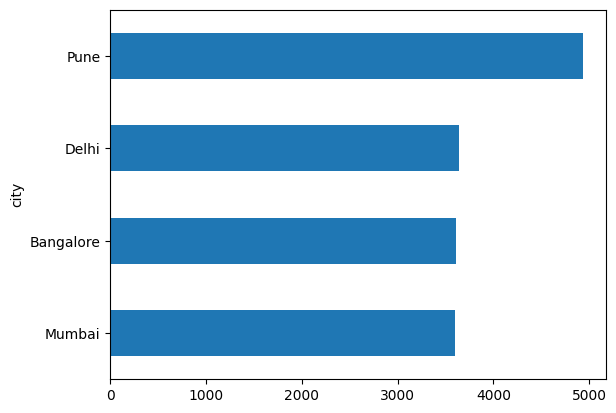

In [ ]:
city_order_average.plot(kind="barh")

In [ ]:
discount_revenue=df.groupby("discount")["revenue"].sum().sort_values()
discount_orders=df.groupby("discount")["order_id"].count().sort_values()
discount_average_revenue=df.groupby("discount")["revenue"].mean().sort_values().round(2)

<Axes: ylabel='discount'>

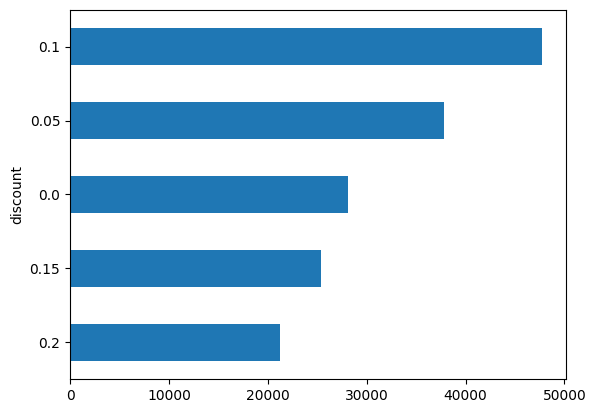

In [ ]:
discount_revenue.plot(kind="barh")

<Axes: ylabel='discount'>

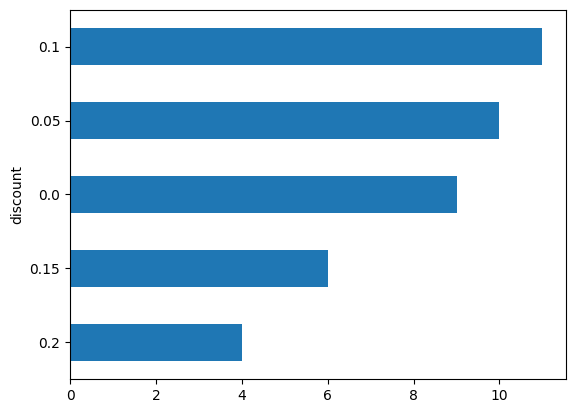

In [ ]:
discount_orders.plot(kind="barh")

<Axes: ylabel='discount'>

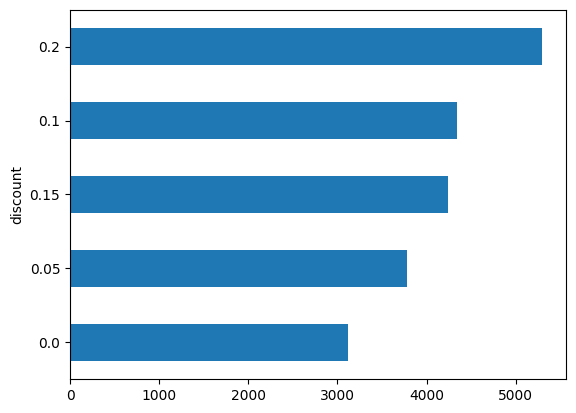

In [ ]:
discount_average_revenue.plot(kind="barh")

In [ ]:
avgerage_delivery_time=df.groupby("city")["delivery_days"].mean().sort_values().round(2)

[Text(0.5, 0, 'days'), Text(0, 0.5, 'rating')]

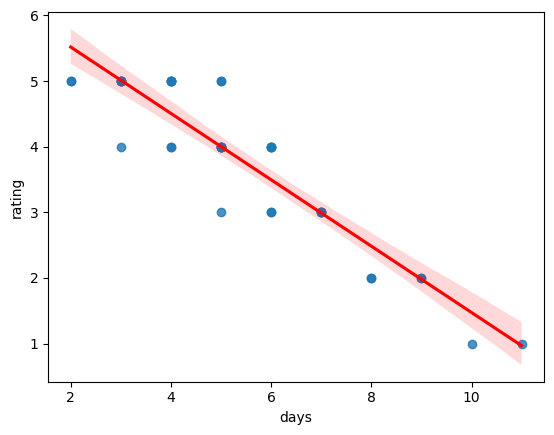

In [ ]:
ax=sns.regplot(data=df,x="delivery_days",y="rating",line_kws={"color":"red"})
ax.set(xlabel="days",ylabel="rating")

In [ ]:
df[df["delivery_days"]>=7].groupby("delivery_days")["rating"].mean()

,rating
delivery_days,
7,3.0
8,2.0
9,2.0
10,1.0
11,1.0


In [ ]:
df[df["delivery_days"]<7].groupby("delivery_days")["rating"].mean().round(1)

,rating
delivery_days,
2,5.0
3,4.8
4,4.7
5,4.1
6,3.7


In [ ]:
late_orders=df[df["delivery_days"]>=7].groupby("delivery_days")["order_id"].count().sum()
late_orders

np.int64(10)

In [ ]:
percent_late=(late_orders/df["order_id"].count())*100
f"{percent_late}%"

'25.0%'

In [ ]:
number_of_orders=df.groupby("customer_id")["order_id"].count().sort_values(ascending=False).head(10)
total_items_purchased=df.groupby("customer_id")["quantity"].sum().sort_values(ascending=False).head(10)
top_10_revenue=df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(10)
top_10_average_revenue=df.groupby("customer_id")["revenue"].mean().sort_values(ascending=False).head(10)

In [ ]:
multiple_orders=df.groupby("customer_id")["order_id"].count().loc[lambda x:x>1].count()
percent_multiple_orders=(multiple_orders/total_orders)*100
f"{percent_multiple_orders}%"

'5.0%'

In [ ]:
np.mean(df["revenue"]).round(2)
np.median(df["revenue"]).round(2)
round(np.std(df["revenue"]),2)
np.min(df["revenue"])
np.max(df["revenue"])
np.percentile(df["revenue"],25).round(2)
np.percentile(df["revenue"],75).round(2)

np.float64(5097.88)

In [ ]:
if np.mean(df["revenue"]).round(2) > np.median(df["revenue"]).round(2):
  print("skewed")
else:
  print("normal")

skewed


# **Conclusions**

### 1. T-shirts and wireless mice have the highest customer ratings, while desks, office chairs, jackets, and bookshelves need improvement.
### 2. Pune has the highest average orders, while Mumbai has relatively lower.
### 3. The results suggest that moderate discounts may provide a better balance between order volume and revenue.
### 4. Longer delivery times are associated with lower customer ratings, suggesting that faster delivery may improve satisfaction.